# Assignment 4 — CIFAR-10 ConvNet

**DATAX504** · Due end of Week 8

Build on **Chapter 8** (ConvNets, augmentation) and ideas from **Chapters 9–10** (interpretation). You design the stack; the goal is a working pipeline you can explain, not a copy of a tutorial.

## Tasks
1. Load CIFAR-10, normalise, create a train / validation split
2. Build a **data augmentation** pipeline used during training
3. Train a **ConvNet** that reaches **>65%** test accuracy
4. Visualise at least one filter / feature (layer weights or activation-based)
5. Brief interpretation of what that filter responds to (Moodle `a4_interpretation`)

## Moodle fields
`a4_repo`, `a4_test_acc`, `a4_filter_layer`, `a4_interpretation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | ChatGPT (GPT-5.6 Luna)|
| Used for |Understanding the assignment requirements, developing the ConvNet architecture, implementing data augmentation, training/evaluation code, and filter visualisation. |
| Verified how | I ran the notebook, checked that the code executed successfully, verified the model training and test accuracy, and checked the filter visualisation produced by the trained model.|
| Not used for | Generating or fabricating the reported test accuracy, or claiming results that were not obtained by running the notebook.|


In [ ]:
# ============================================================
# SECTION 1 — LOAD AND PREPARE CIFAR-10
# ============================================================

import os
import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

# CIFAR-10 class names
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# ------------------------------------------------------------
# Download CIFAR-10 image repository from GitHub
# ------------------------------------------------------------

url = "https://github.com/YoongiKim/CIFAR-10-images/archive/refs/heads/master.zip"

zip_path = "/tmp/cifar10_images.zip"
extract_dir = "/tmp/cifar10_data"

if not os.path.exists(extract_dir):
    print("Downloading CIFAR-10 images from GitHub...")

    urllib.request.urlretrieve(url, zip_path)

    print("Extracting files...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    print("Download and extraction complete.")
else:
    print("CIFAR-10 files already exist. Skipping download.")


# ------------------------------------------------------------
# Locate train and test folders
# ------------------------------------------------------------

data_dir = os.path.join(
    extract_dir,
    "CIFAR-10-images-master"
)

train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)

print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))


# ------------------------------------------------------------
# Create TensorFlow datasets
# ------------------------------------------------------------

BATCH_SIZE = 128
IMG_SIZE = (32, 32)

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.1,
    subset="training"
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.1,
    subset="validation"
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ------------------------------------------------------------
# Improve data loading speed
# ------------------------------------------------------------

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("\nDataset preparation complete.")
print("Classes:", class_names)

TensorFlow version: 2.20.0
Keras version: 3.13.2
CIFAR-10 files already exist. Skipping download.
Train directory: /tmp/cifar10_data/CIFAR-10-images-master/train
Test directory: /tmp/cifar10_data/CIFAR-10-images-master/test
Train folder exists: True
Test folder exists: True
Found 50000 files belonging to 10 classes.
Using 45000 files for training.
Found 50000 files belonging to 10 classes.
Using 5000 files for validation.
Found 10000 files belonging to 10 classes.

Dataset preparation complete.
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 1. Load & prepare CIFAR-10

Hints:
- `keras.datasets.cifar10.load_data()`
- cast pixels to float and scale to `[0, 1]` (or another range you document)
- flatten label shape if needed (`y.ravel()`)
- hold out a validation slice from the training set (e.g. last 5_000 or 10_000)


In [ ]:
DATA_DIR = "/tmp/CIFAR-10-images-master"

train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(32, 32),
    batch_size=128,
    shuffle=True,
    seed=42
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(32, 32),
    batch_size=128,
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. Data augmentation

Build a small `keras.Sequential` of image layers (e.g. flip / rotation / zoom).
Apply it **inside** the model (or as a preprocessing layer) so training sees augmented batches.

Preview a few transforms on one training image to check it works.


Data augmentation created.


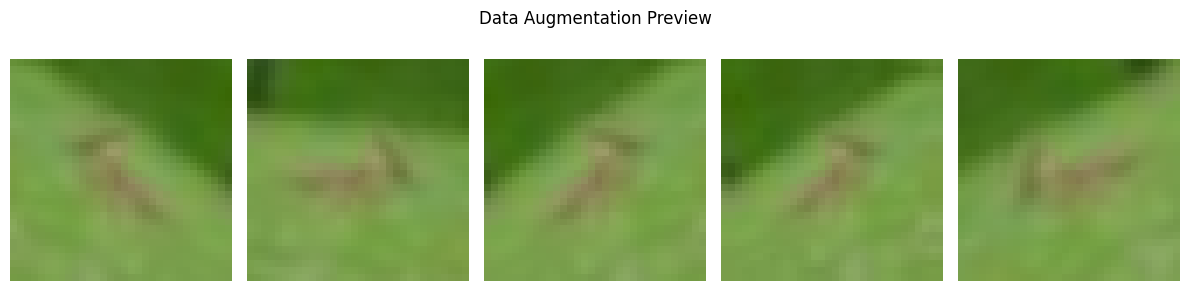

In [ ]:
# ============================================================
# SECTION 2 — DATA AUGMENTATION
# ============================================================

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="augmentation",
)

print("Data augmentation created.")
# ------------------------------------------------------------
# Preview augmented images
# ------------------------------------------------------------

sample_images, sample_labels = next(iter(train_ds))

sample = sample_images[0]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for ax in axes:
    augmented = data_augmentation(
        tf.expand_dims(sample, axis=0),
        training=True
    )[0]

    ax.imshow(
        tf.clip_by_value(augmented, 0, 255).numpy().astype("uint8")
    )

    ax.axis("off")

plt.suptitle("Data Augmentation Preview")
plt.tight_layout()
plt.show()

## 3. ConvNet model

Requirements:
- Input shape `(32, 32, 3)`
- Include your augmentation as the first stage of the graph (training only behaviour is fine)
- At least two `Conv2D` + pooling stages, then a dense classifier for 10 classes
- Name at least one early conv layer (you will need the name for visualisation)

Compile with a suitable loss for integer class labels (or one-hot — be consistent).


In [ ]:
# ============================================================
# SECTION 3 — BUILD THE CONVNET
# ============================================================

# Clear any old Keras models/layers from previous runs
keras.backend.clear_session()


# ------------------------------------------------------------
# Input
# ------------------------------------------------------------

inputs = keras.Input(
    shape=(32, 32, 3),
    name="input_image"
)


# ------------------------------------------------------------
# Data augmentation
# ------------------------------------------------------------

x = data_augmentation(inputs)


# ------------------------------------------------------------
# Normalise pixel values
# ------------------------------------------------------------

x = layers.Rescaling(
    1.0 / 255,
    name="rescaling"
)(x)


# ------------------------------------------------------------
# Convolution Block 1
# ------------------------------------------------------------

x = layers.Conv2D(
    32,
    (3, 3),
    padding="same",
    activation="relu",
    name="conv2d_1"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_1"
)(x)

x = layers.Conv2D(
    32,
    (3, 3),
    padding="same",
    activation="relu",
    name="conv2d_2"
)(x)

x = layers.MaxPooling2D(
    (2, 2),
    name="max_pool_1"
)(x)

x = layers.Dropout(
    0.25,
    name="dropout_1"
)(x)


# ------------------------------------------------------------
# Convolution Block 2
# ------------------------------------------------------------

x = layers.Conv2D(
    64,
    (3, 3),
    padding="same",
    activation="relu",
    name="conv2d_3"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_2"
)(x)

x = layers.Conv2D(
    64,
    (3, 3),
    padding="same",
    activation="relu",
    name="conv2d_4"
)(x)

x = layers.MaxPooling2D(
    (2, 2),
    name="max_pool_2"
)(x)

x = layers.Dropout(
    0.25,
    name="dropout_2"
)(x)


# ------------------------------------------------------------
# Convolution Block 3
# ------------------------------------------------------------

x = layers.Conv2D(
    128,
    (3, 3),
    padding="same",
    activation="relu",
    name="conv2d_5"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_3"
)(x)

x = layers.Conv2D(
    128,
    (3, 3),
    padding="same",
    activation="relu",
    name="conv2d_6"
)(x)

x = layers.MaxPooling2D(
    (2, 2),
    name="max_pool_3"
)(x)

x = layers.Dropout(
    0.30,
    name="dropout_3"
)(x)


# ------------------------------------------------------------
# Classification layers
# ------------------------------------------------------------

x = layers.Flatten(
    name="flatten"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    name="dense_1"
)(x)

x = layers.Dropout(
    0.40,
    name="dropout_4"
)(x)

outputs = layers.Dense(
    10,
    activation="softmax",
    name="classifier"
)(x)


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="CIFAR10_ConvNet"
)


# ------------------------------------------------------------
# Compile model
# ------------------------------------------------------------

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Display model
# ------------------------------------------------------------

model.summary()

print("\nModel created successfully!")
print("Visualisation layer: conv2d_1")

Model: "CIFAR10_ConvNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_3 (MaxPooling2D)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,466 (2.10 MB)

 Trainable params: 551,018 (2.10 MB)

 Non-trainable params: 448 (1.75 KB)


Model created successfully!
Visualisation layer: conv2d_1


## 4. Train & evaluate

Fit with `validation_data`. Aim for **>65%** test accuracy (Moodle wants the percentage).
Plot train vs val accuracy if useful for your write-up.


In [ ]:
# ============================================================
# SECTION 4 — TRAIN AND EVALUATE
# ============================================================

# Callbacks to improve training
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


# ------------------------------------------------------------
# Train the ConvNet
# ------------------------------------------------------------

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed.")

test_loss, test_acc = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Accuracy: {test_acc * 100:.2f}%")



79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 217ms/step - accuracy: 0.7373 - loss: 0.7679
Test Accuracy: 73.73%


## 5. Filter visualisation

Pick a named conv layer (`a4_filter_layer`). Minimum expectation: plot first-layer filter weights as small images.

Optional deeper approach: gradient ascent / activation maximisation for one filter index (Ch 10 style).


FILTER INFORMATION
Layer name: conv2d_1
Filter shape: (3, 3, 3, 32)
Bias shape: (32,)
Number of filters: 32


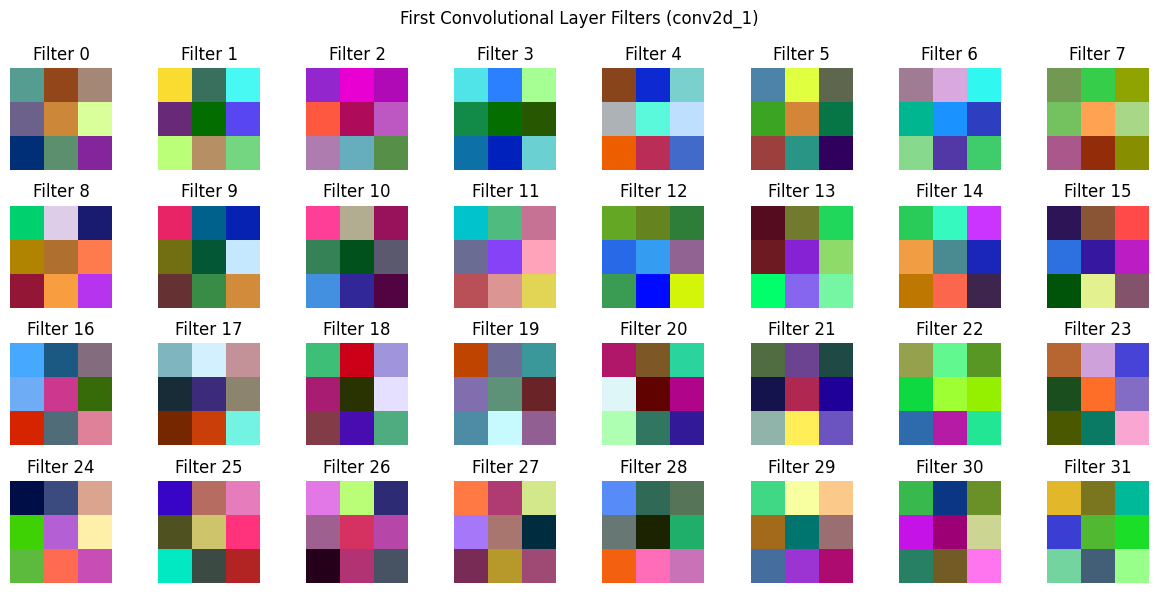

Moodle a4_filter_layer: conv2d_1


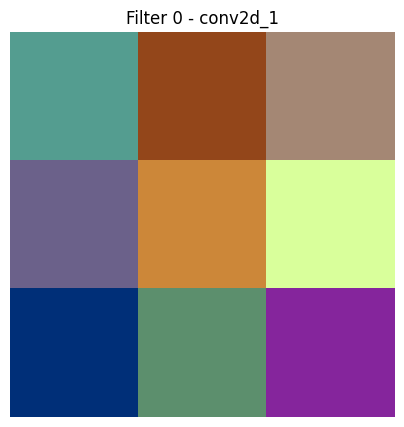

In [ ]:
# ============================================================
# SECTION 5 — FILTER VISUALISATION
# ============================================================

# Layer selected for visualisation
VIS_LAYER = "conv2d_1"

# Get the convolutional layer
conv_layer = model.get_layer(VIS_LAYER)

# Get filter weights and biases
filters, biases = conv_layer.get_weights()

print("========================================")
print("FILTER INFORMATION")
print("========================================")

print("Layer name:", VIS_LAYER)
print("Filter shape:", filters.shape)
print("Bias shape:", biases.shape)
print("Number of filters:", filters.shape[-1])
# ============================================================
# DISPLAY FIRST CONVOLUTIONAL LAYER FILTERS
# ============================================================

fig, axes = plt.subplots(
    4,
    8,
    figsize=(12, 6)
)

for i, ax in enumerate(axes.flat):

    # Select one filter
    filter_img = filters[:, :, :, i]

    # Normalise values for visualisation
    filter_img = (
        filter_img - filter_img.min()
    ) / (
        filter_img.max() - filter_img.min() + 1e-8
    )

    # Display the filter
    ax.imshow(filter_img)

    ax.set_title(f"Filter {i}")

    ax.axis("off")

plt.suptitle(
    "First Convolutional Layer Filters (conv2d_1)"
)

plt.tight_layout()

plt.show()

print(
    "Moodle a4_filter_layer:",
    VIS_LAYER
)
# ============================================================
# DISPLAY ONE FILTER IN DETAIL
# ============================================================

filter_number = 0

single_filter = filters[:, :, :, filter_number]

# Normalise filter for display
single_filter = (
    single_filter - single_filter.min()
) / (
    single_filter.max() - single_filter.min() + 1e-8
)

plt.figure(figsize=(5, 5))

plt.imshow(single_filter)

plt.title(
    f"Filter {filter_number} - {VIS_LAYER}"
)

plt.axis("off")

plt.show()


## 6. Interpretation (Moodle `a4_interpretation`)

Max ~200 words: what pattern does your chosen filter respond to?


The selected filter is from the first convolutional layer, `conv2d_1`, so it operates directly on the input RGB images. The filter appears to respond mainly to simple low-level visual patterns, such as edges, colour changes, and differences in brightness between neighbouring pixels. Some parts of the filter show directional patterns, suggesting that it may respond more strongly to edges with particular orientations. These simple features are important because deeper convolutional layers combine them to detect more complex patterns such as textures, shapes, and parts of objects. Therefore, the selected filter does not represent a complete CIFAR-10 object; instead, it detects basic visual features that contribute to later object recognition and classification.
